## Pre-amble

Contrast vs Resolution

What happens to big and small objects when convolved?

We have been discussing 2d deconvolution vs 'deconvolve 2d slice in 3d'

Does the latter give better resolution?  No. 

Does the latter give better contrast?  That is an interesting question.

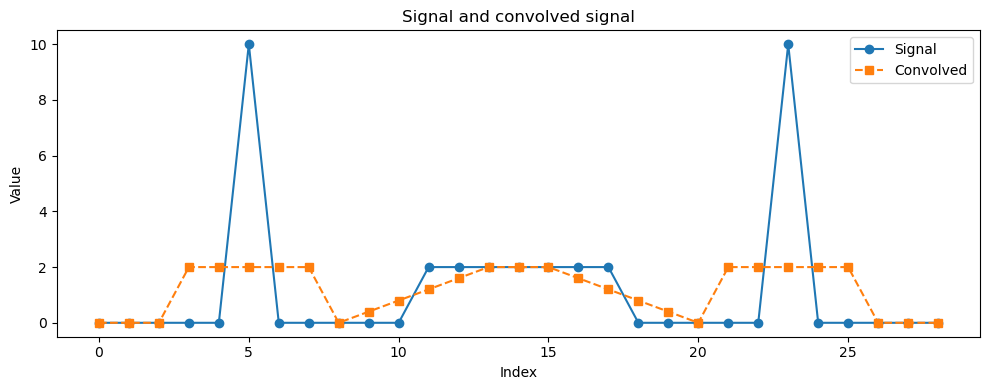

In [2]:
import numpy as np
import matplotlib.pyplot as plt

signal = np.array([0,0,0,0,0,10,0,0,0,0,0,2,2,2,2,2,2,2,0,0,0,0,0,10,0,0,0,0,0], dtype=float)
kernel = np.array([1,1,1,1,1], dtype=float) / 5

convolved = np.convolve(signal, kernel, mode='same')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(signal, 'o-', label='Signal')
ax.plot(convolved, 's--', label='Convolved')
ax.set_xlabel('Index')
ax.set_ylabel('Value')
ax.set_title('Signal and convolved signal')
ax.legend()
plt.tight_layout()
plt.show()

# Let's make PSF so we can try something in 3D

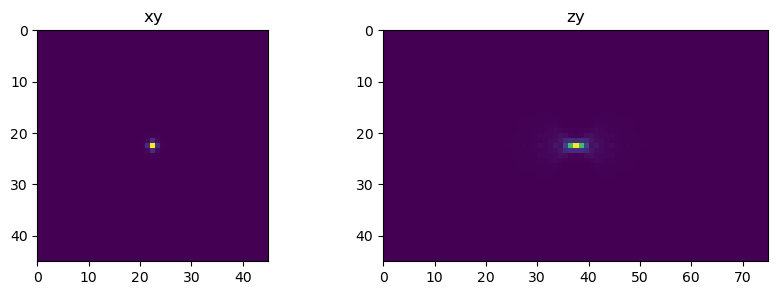

In [3]:
from tnia.deconvolution.psfs import gibson_lanni_3D
from tnia.plotting.projections import show_xy_zy_slice_center
import numpy as np
import matplotlib.pyplot as plt

xy_psf_dim = 45
NA = 1.4
x_voxel_size = 0.185
z_voxel_size = 0.185
z_psf_dim = 75
wl = .500
ni = 1.5
ns = 1.5
defocus = 0

psf = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wl, use_psfm=True)
psf = np.squeeze(psf.astype('float32'))

from tnia.plotting.projections import show_xy_zy_slice_center

fig = show_xy_zy_slice_center(psf)




## Big objects and 2 intensity populations of small objects

Put the big objects behind the small objects.  Make them dimmer.  

And lets have two distinct populations, intensities of exactly 1000 and intensities of 2000.

What will happen after convolution?  

Hypothesis: Bright larger objects will leak signal onto plane with small objects, Small objects intensities will leak into other planes and out relative intensity measurements will be a bit messed up. 

What will happen after deconvolution?

Ideal:  Intensities restored so we have 2 populations again.  

Test 3 methods to see if (in simnple naive noiseless simulation) they have this property

Method 1: 2D Deconvolution
Method 2: Deconvolve 2D plane with 3D PSF in 3D Space
Method 3: Full 3D Deconvolution



4 spheres at [(25, 40, 40), (25, 40, 89), (25, 89, 40), (25, 89, 89)], radius=18, 100 random dots


Text(0.5, 0.98, '4 spheres + random dots phantom')

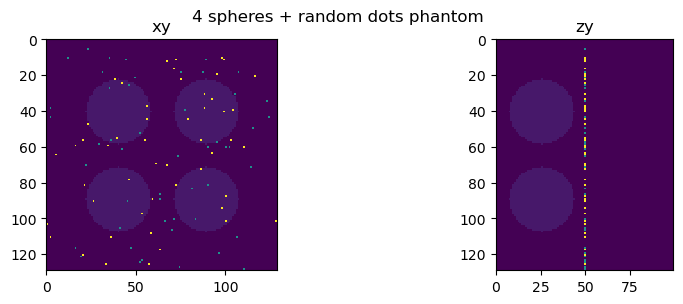

In [51]:
from tnia.plotting.projections import show_xy_zy_max

z_dim = 99

phantom = np.zeros((z_dim, 129, 129), dtype=np.float32)

intensity1 = 20000
intensity2 = 40000

# 4 smaller spheres of radius 12
radius = 18
sphere_centers = [
    (25, 40, 40),
    (25, 40, 89),
    (25, 89, 40),
    (25, 89, 89),
]
zz, yy, xx = np.ogrid[:z_dim, :129, :129]
for sc in sphere_centers:
    dist = np.sqrt((zz - sc[0])**2 + (yy - sc[1])**2 + (xx - sc[2])**2)
    phantom[dist <= radius] = 2500

# lots of small single-point dots
rng = np.random.default_rng(42)
n_dots = 100
for _ in range(n_dots):
    z = z_dim//2
    y = rng.integers(0, 129)
    x = rng.integers(0, 129)
    intensity = rng.choice([intensity1, intensity2])
    phantom[z, y, x] = intensity

print(f'4 spheres at {sphere_centers}, radius={radius}, {n_dots} random dots')
fig = show_xy_zy_max(phantom)
fig.suptitle('4 spheres + random dots phantom')

## Now lets convolve them

1312.0 0.0
1312.0 0.0


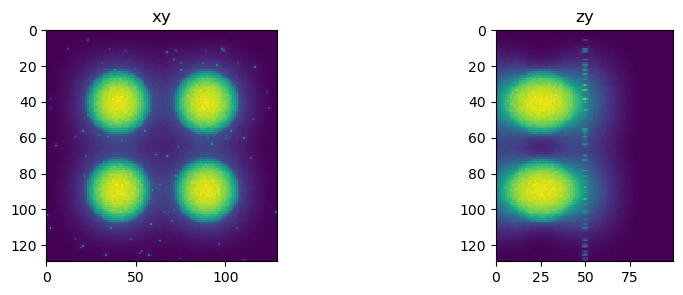

In [52]:
from tnia.deconvolution.forward import forward 

image = forward(phantom, psf, 5, add_poisson=True, gpu=True)
print(image.max(), image.min())
image[image<0]=0
image[image<0]=0
print(image.max(), image.min())

fig = show_xy_zy_max(image)

# Try 3 decon methods

1.  2D
2.  3D PSF and solution space but 2D input
3.  Full 3D

In [56]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp

iterations = 2000

print('--- Running 2D decon ---')
input_slice = image[image.shape[0]//2, :, :]
psf_2d = psf[psf.shape[0]//2] / psf[psf.shape[0]//2].sum()
deconvolved_2d = richardson_lucy_cp(input_slice, psf_2d, iterations)

print()
print('--- Running 2D slice → 3D decon ---')
# add trivial dimension
input_slice = input_slice[np.newaxis, :, :]
deconvolved_2d_3d = richardson_lucy_cp(input_slice, psf, iterations, noncirc=True, do_unpad=True)
deconvolved_2d_3d[deconvolved_2d_3d<0]=0

print()
print('--- Running full 3D decon ---')

deconvolved_3d = richardson_lucy_cp(image, psf, iterations, noncirc=True)


--- Running 2D decon ---
Input size: (129, 129), PSF size: (45, 45)
Input is 2D, PSF is 2D

0 10 20 30 40 50 

60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510 520 530 540 550 560 570 580 590 600 610 620 630 640 650 660 670 680 690 700 710 720 730 740 750 760 770 780 790 800 810 820 830 840 850 860 870 880 890 900 910 920 930 940 950 960 970 980 990 1000 1010 1020 1030 1040 1050 1060 1070 1080 1090 1100 1110 1120 1130 1140 1150 1160 1170 1180 1190 1200 1210 1220 1230 1240 1250 1260 1270 1280 1290 1300 1310 1320 1330 1340 1350 1360 1370 1380 1390 1400 1410 1420 1430 1440 1450 1460 1470 1480 1490 1500 1510 1520 1530 1540 1550 1560 1570 1580 1590 1600 1610 1620 1630 1640 1650 1660 1670 1680 1690 1700 1710 1720 1730 1740 1750 1760 1770 1780 1790 1800 1810 1820 1830 1840 1850 1860 1870 1880 1890 1900 1910 1920 1930 1940 1950 1960 1970 1980 1990 

--- Running 2D slice → 3D decon ---
Input size: (1, 129, 129), PSF size: (75, 45, 45)
Input is 2D (single Z plane), PSF is 3D


## Take a look at results

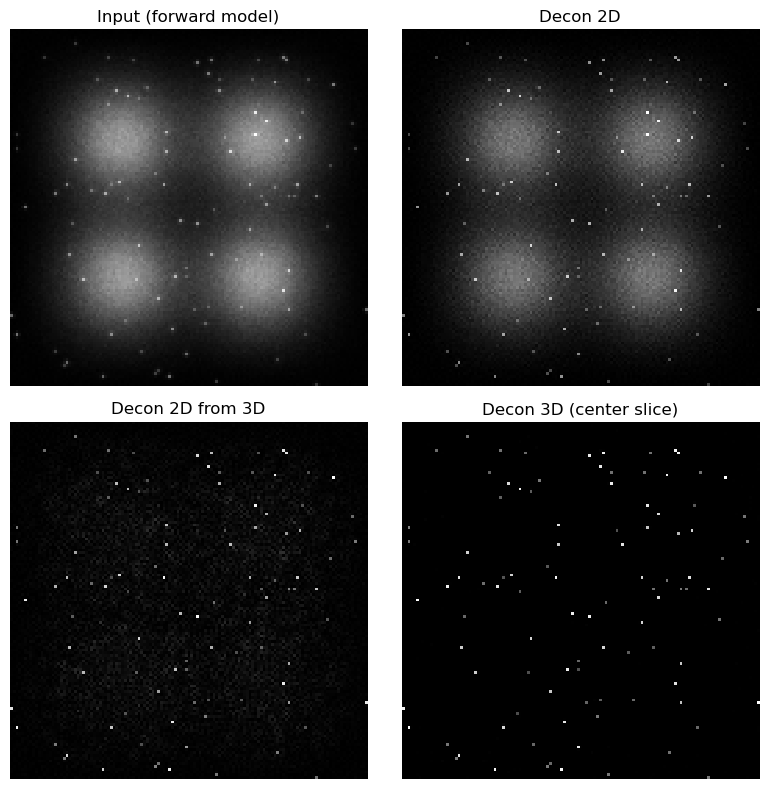

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(input_slice.squeeze(), cmap='gray')
axes[0, 0].set_title('Input (forward model)')
axes[0, 0].axis('off')
axes[0, 1].imshow(deconvolved_2d.squeeze(), cmap='gray')
axes[0, 1].set_title('Decon 2D')
axes[0, 1].axis('off')
axes[1, 0].imshow(deconvolved_2d_3d.squeeze(), cmap='gray')
axes[1, 0].set_title('Decon 2D from 3D')
axes[1, 0].axis('off')
axes[1, 1].imshow(deconvolved_3d[deconvolved_3d.shape[0]//2], cmap='gray')
axes[1, 1].set_title('Decon 3D (center slice)')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

## Can we separate the two populations??

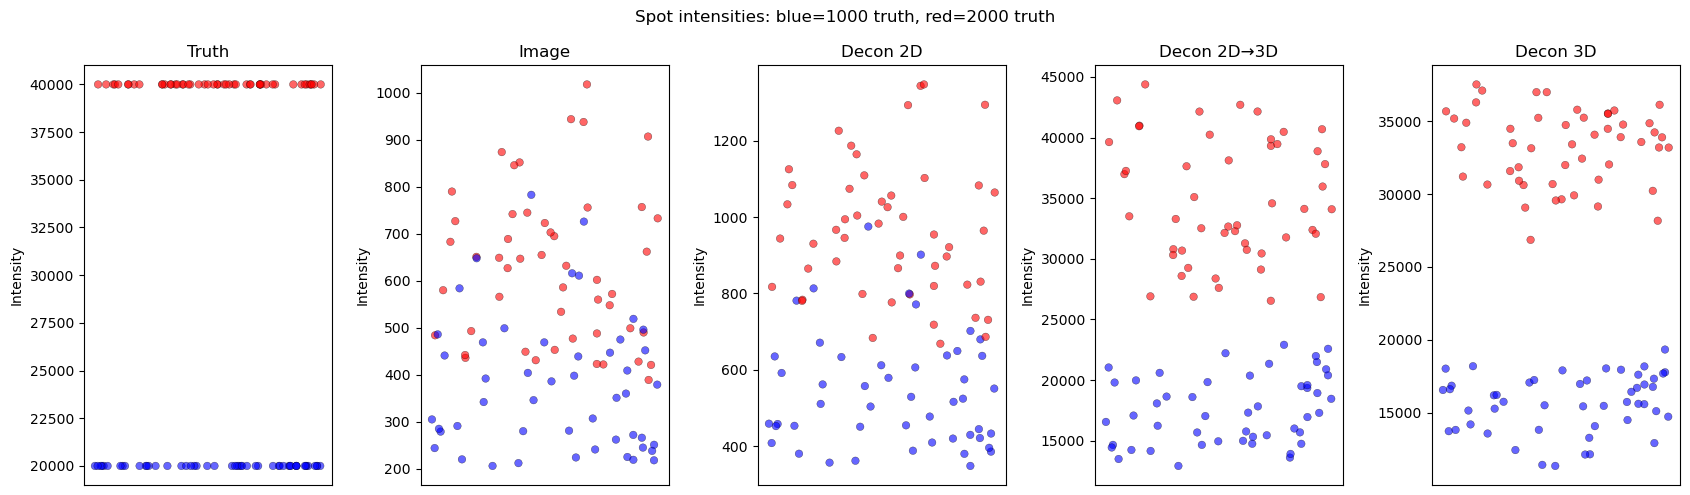

In [59]:
from skimage.feature import peak_local_max

center_z = phantom.shape[0] // 2
true_positions = np.argwhere(phantom[center_z] > 0)

# truth: get dot positions and intensities at center z (exclude sphere voxels)
truth_intensities = phantom[center_z][true_positions[:, 0], true_positions[:, 1]]

# image intensities at truth positions
image_intensities = image[center_z][true_positions[:, 0], true_positions[:, 1]]

# decon 2d intensities at truth positions
decon2d_sq = deconvolved_2d.squeeze()
decon2d_intensities = decon2d_sq[true_positions[:, 0], true_positions[:, 1]]

# decon 2d from 3d intensities at truth positions
decon2d3d_sq = deconvolved_2d_3d.squeeze()
decon2d3d_intensities = decon2d3d_sq[true_positions[:, 0], true_positions[:, 1]]

# decon 3d intensities at truth positions
decon3d_center = deconvolved_3d[deconvolved_3d.shape[0] // 2]
decon3d_intensities = decon3d_center[true_positions[:, 0], true_positions[:, 1]]

# color by true population
colors = ['blue' if v == intensity1 else 'red' for v in truth_intensities]

fig, axes = plt.subplots(1, 5, figsize=(17, 5), sharey=False)
labels = ['Truth', 'Image', 'Decon 2D', 'Decon 2D→3D', 'Decon 3D']
data = [truth_intensities, image_intensities, decon2d_intensities, decon2d3d_intensities, decon3d_intensities]

for ax, vals, label in zip(axes, data, labels):
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(vals))
    ax.scatter(jitter, vals, c=colors, alpha=0.6, edgecolors='k', linewidths=0.3, s=30)
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_ylabel('Intensity')
    for pop_val, pop_color in [(1000, 'blue'), (2000, 'red')]:
        mask = truth_intensities == pop_val
        if mask.any():
            med = np.median(vals[mask])
            ax.axhline(med, color=pop_color, linestyle='--', alpha=0.7, linewidth=1.5)

fig.suptitle('Spot intensities: blue=1000 truth, red=2000 truth', fontsize=12)
plt.tight_layout()
plt.show()

## Questions

Is the apparent better contrast from 'deconvolve 2d slice in 3d space' real?   

Hypothesis:  The big blurry objects are actually not changing much, it's the small objects that are getting brighter.  

Input size: (1, 129, 129), PSF size: (75, 45, 45)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0 



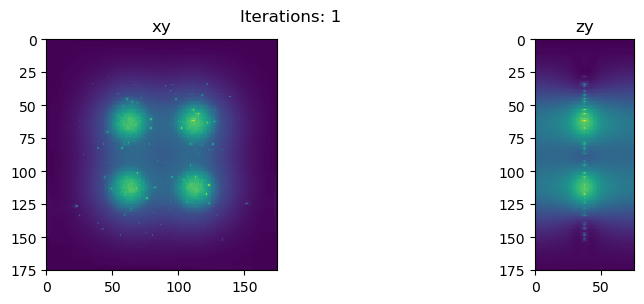

Input size: (1, 129, 129), PSF size: (75, 45, 45)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0 



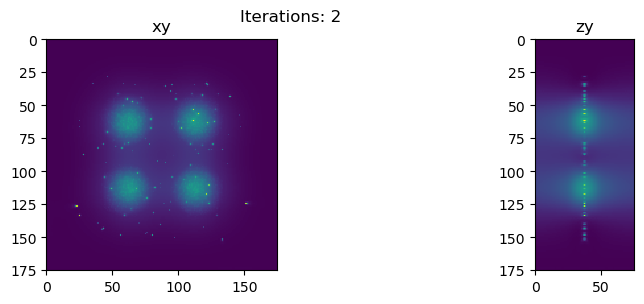

Input size: (1, 129, 129), PSF size: (75, 45, 45)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0 



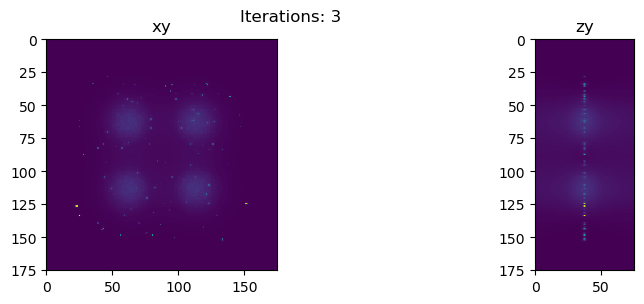

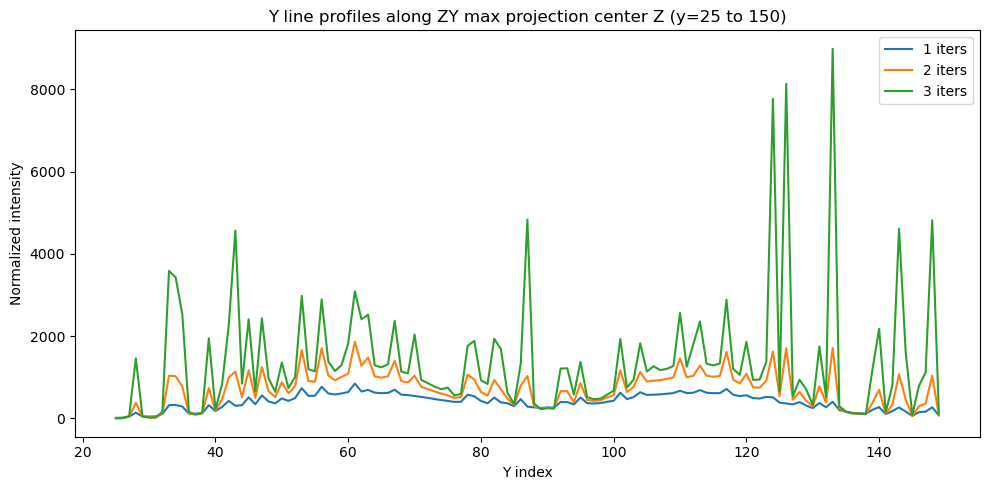

In [60]:
iterations = [1, 2, 3]

line_profiles = {}

for iter in iterations:
    deconvolved_2d_3d_full, _ = richardson_lucy_cp(input_slice, psf, iter, noncirc=True, do_unpad=False)
    fig = show_xy_zy_max(deconvolved_2d_3d_full)
    fig.suptitle(f'Iterations: {iter}')
    plt.show()
    
    # ZY max projection: collapse x axis -> shape (z, y)
    zy_proj = deconvolved_2d_3d_full.max(axis=2)
    # extract line along y at center z, from y=25 to y=150
    center_z = zy_proj.shape[0] // 2
    y_line = zy_proj[center_z, 25:150]
    line_profiles[iter] = y_line

# plot all y line profiles
fig, ax = plt.subplots(figsize=(10, 5))
for iter, profile in line_profiles.items():
    ax.plot(np.arange(25, 150), profile, label=f'{iter} iters')
ax.set_xlabel('Y index')
ax.set_ylabel('Normalized intensity')
ax.set_title('Y line profiles along ZY max projection center Z (y=25 to 150)')
ax.legend()
plt.tight_layout()
plt.show()